# 09 — Joint Inference: Detection + Lane Segmentation

**Goal:** Run inference with the jointly trained model showing both detection boxes and lane mask overlay.

This notebook:
1. Loads joint-trained weights
2. Runs the multi-task model on images
3. Draws detection bounding boxes
4. Overlays predicted lane mask
5. Saves annotated images

### Prerequisites
- Run `08_joint_training.ipynb` first (or have joint weights ready)

## 1 — Setup

In [1]:
!pip install -q ultralytics>=8.4.0 opencv-python matplotlib pyyaml

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
DATASET_DIR = "/content/bdd100k_yolo"
os.makedirs(DATASET_DIR, exist_ok=True)

# ----------------- ADDED: TAR EXTRACTION -----------------
# Restore images from notebook 02's tar to avoid Drive FUSE overhead
# Only extract if local images directory does not exist
NB02_TAR = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo_nb02.tar")

if not os.path.isdir(os.path.join(DATASET_DIR, "images", "val")):
    if os.path.isfile(NB02_TAR):
        print("📦 Extracting images from tar...")
        !tar -xf "{NB02_TAR}" -C {DATASET_DIR}
        print("✅ Images ready locally")
    else:
        print(f"❌ {NB02_TAR} not found! Run Notebook 02 first.")
else:
    print("✅ Local images already exist")

# ----------------- ADDED: MASK EXTRACTION -----------------
# Restore masks from notebook 07's tar
masks_dir = os.path.join(DATASET_DIR, "masks")
masks_tar = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo", "masks.tar")

if not os.path.isdir(masks_dir):
    if os.path.isfile(masks_tar):
        print("📦 Extracting masks from tar...")
        !cp "{masks_tar}" /content/ && tar -xf /content/masks.tar -C /content/
        print("✅ Masks ready locally")
    else:
        print(f"❌ {masks_tar} not found! Run Notebook 07 first.")
else:
    print("✅ Local masks already exist")
# ---------------------------------------------------------

# Add project src to path
PROJECT_SRC = os.path.join(ECOCAR_ROOT, "project", "src")
if os.path.isdir(PROJECT_SRC):
    sys.path.insert(0, os.path.dirname(PROJECT_SRC))

# Joint weights path
JOINT_WEIGHTS = os.path.join(ECOCAR_ROOT, "weights", "joint_det_lane_best.pt")

# Output
OUTPUT_DIR = os.path.join(ECOCAR_ROOT, "outputs", "09_joint_inference")
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"Weights: {JOINT_WEIGHTS} (exists: {os.path.isfile(JOINT_WEIGHTS)})")


📦 Extracting images from tar...
✅ Images ready locally
📦 Extracting masks from tar...
✅ Masks ready locally
Device: cuda
Weights: /content/drive/MyDrive/EcoCAR/weights/joint_det_lane_best.pt (exists: True)


## 2 — Load Multi-Task Model

In [4]:
from src.multitask_model import build_multitask_model

# Build with same architecture config as training
model = build_multitask_model(
    weights='yolo26s.pt',
    lane_head_type='light_muster',
    lane_embed_dim=96,
    lane_num_heads=4,
    lane_depth=2,
    mask_height=180,
    mask_width=320
)

# Load joint-trained weights
if os.path.isfile(JOINT_WEIGHTS):
    ckpt = torch.load(JOINT_WEIGHTS, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'], strict=False)
    print(f"✅ Loaded joint weights from epoch {ckpt.get('epoch', '?')}")
else:
    print("⚠️ Joint weights not found. Using untrained model (for demo only).")

model = model.to(device)
model.eval()
print("Model ready for inference.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ MultiTaskYOLO built:
   Backbone+Neck layers: 23
   Detect head: Detect
   Neck output indices: [16, 19, 22]
   Neck channels: [128, 256, 512]
   Lane head params: 1,559,041
✅ Loaded joint weights from epoch 9
Model ready for inference.


## 3 — Select Test Images

In [5]:
val_images_dir = os.path.join(DATASET_DIR, 'images', 'val')
NUM_SAMPLES = 6

if os.path.isdir(val_images_dir):
    all_imgs = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir)
                if f.endswith(('.jpg', '.png'))]
    test_images = random.sample(all_imgs, min(NUM_SAMPLES, len(all_imgs)))
    print(f"✅ Selected {len(test_images)} images")
else:
    print(f"❌ Val dir not found: {val_images_dir}")
    test_images = []

✅ Selected 6 images


## 4 — Run Joint Inference

💾 Saved to /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/joint_56c872b0-b1682777.png


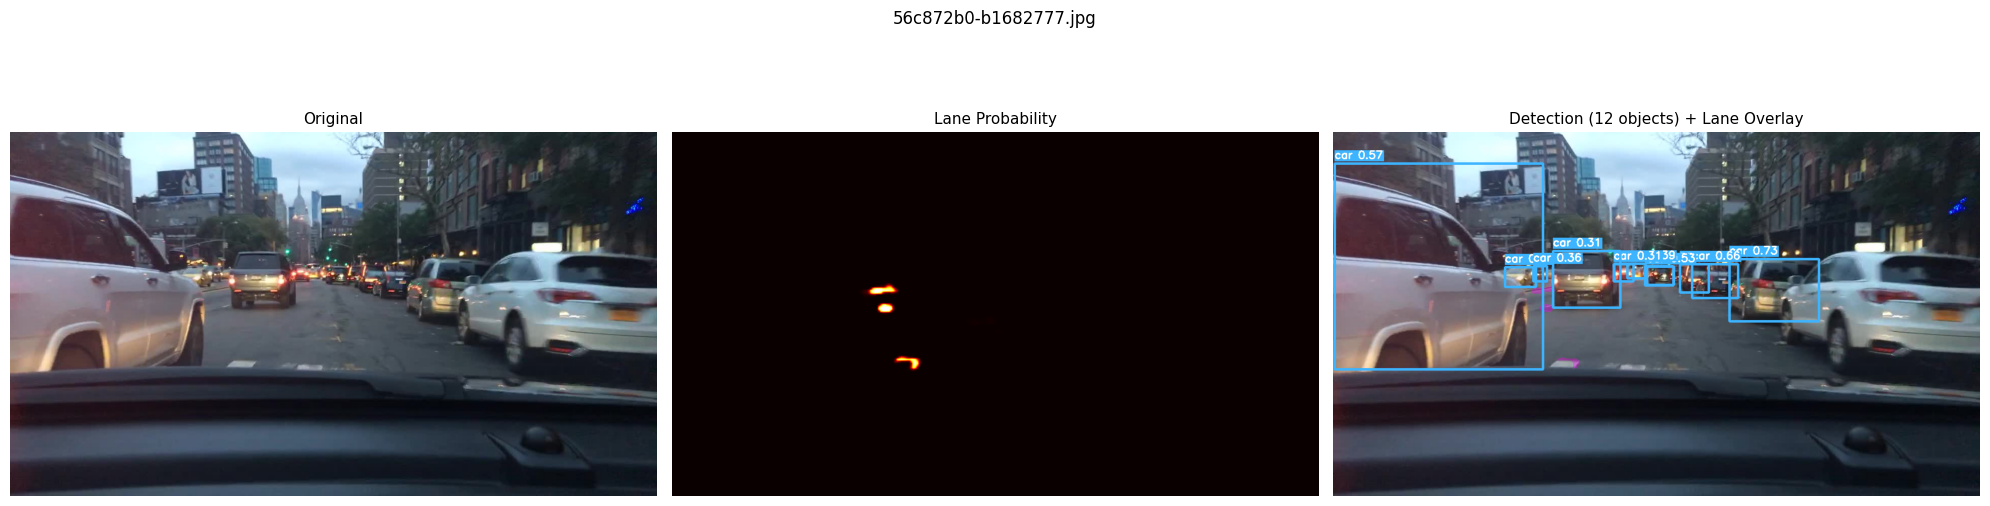

  Objects Detected: 12
  Lane coverage: 0.1% of image

💾 Saved to /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/joint_2857a806-65564a6a.png


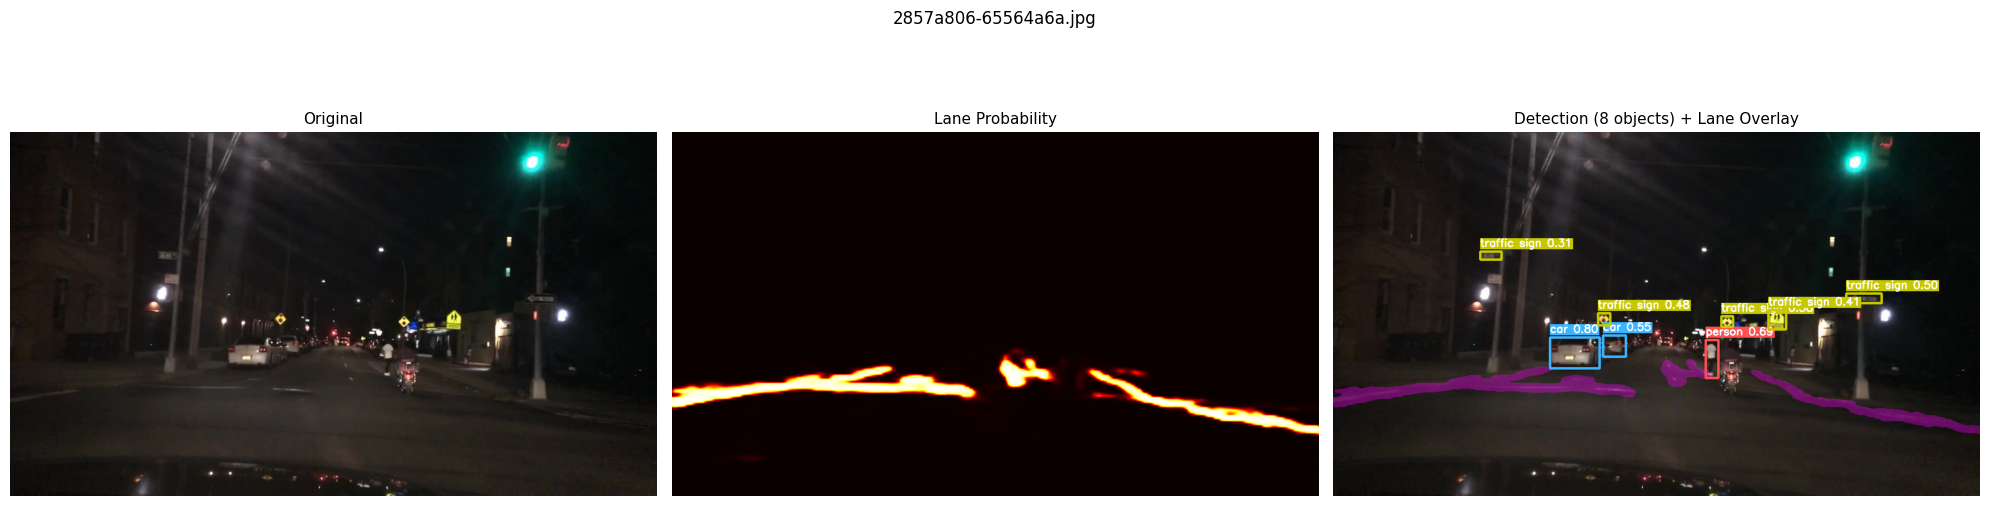

  Objects Detected: 8
  Lane coverage: 3.0% of image

💾 Saved to /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/joint_5a9f078b-3e20ead7.png


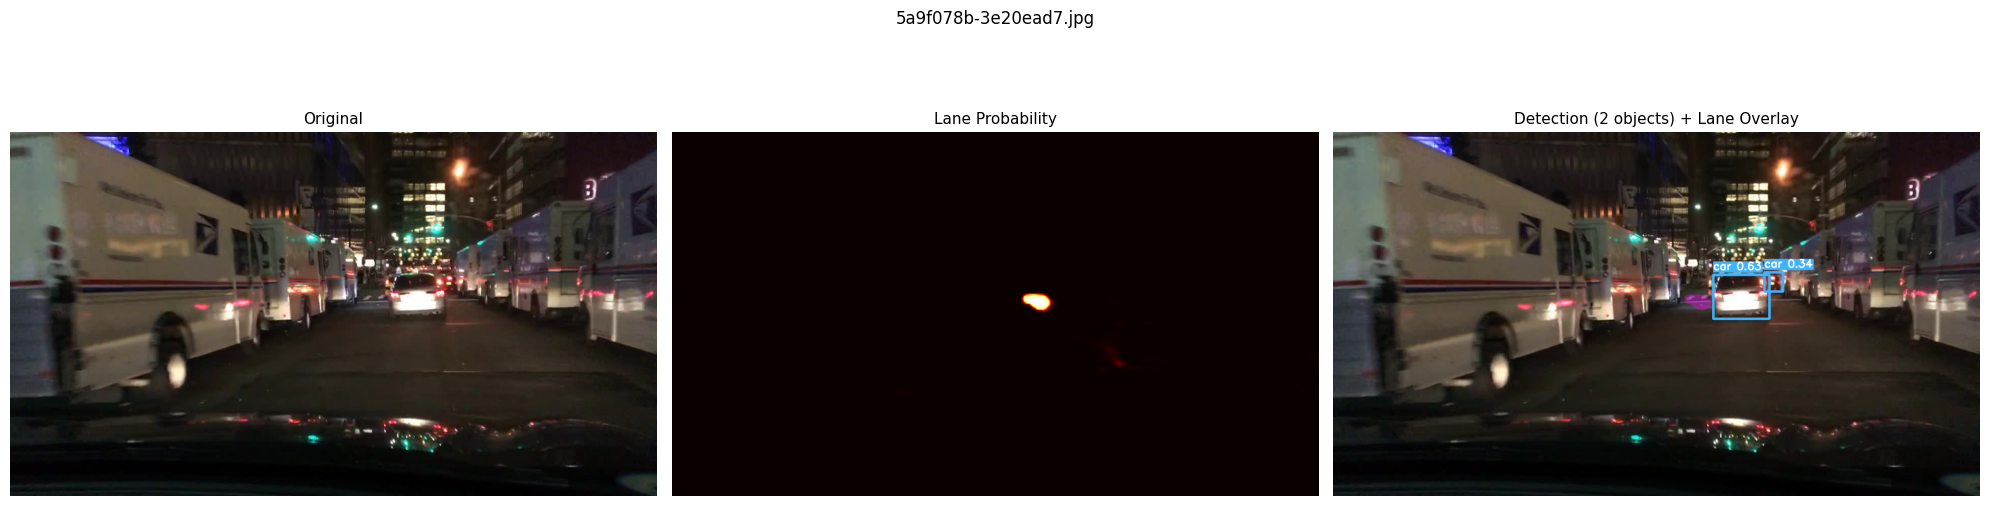

  Objects Detected: 2
  Lane coverage: 0.1% of image

💾 Saved to /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/joint_45a5fbad-084caf46.png


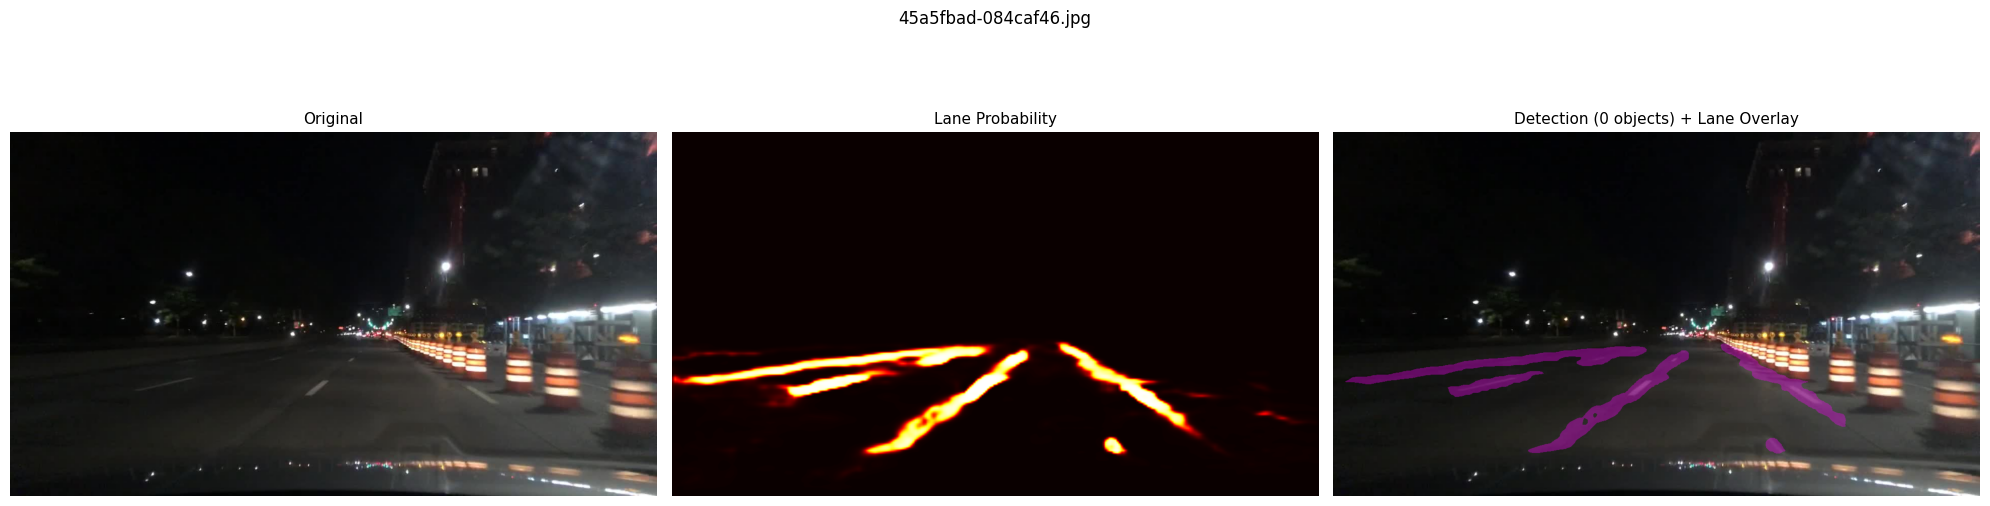

  Objects Detected: 0
  Lane coverage: 3.4% of image

💾 Saved to /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/joint_1d776d8e-353e1a09.png


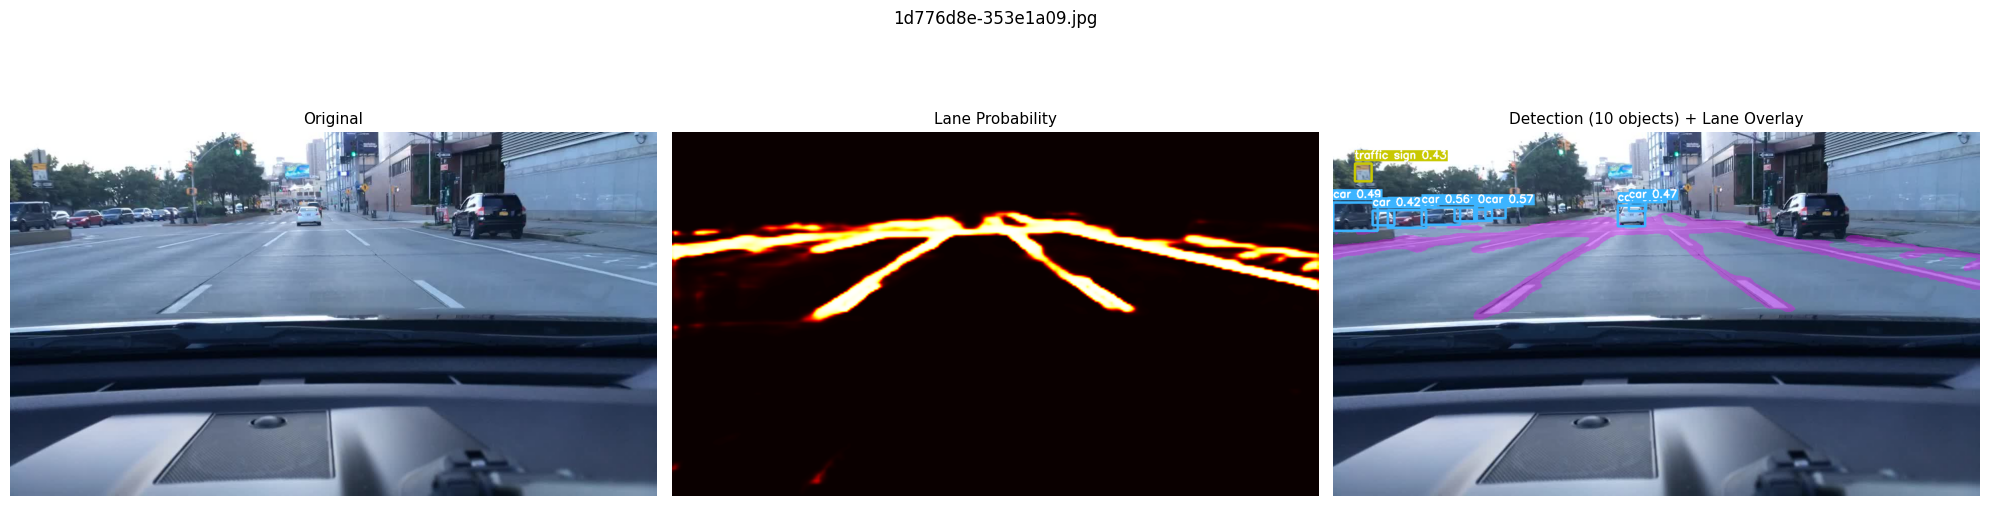

  Objects Detected: 10
  Lane coverage: 5.6% of image

💾 Saved to /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/joint_6e01fc6d-108f4430.png


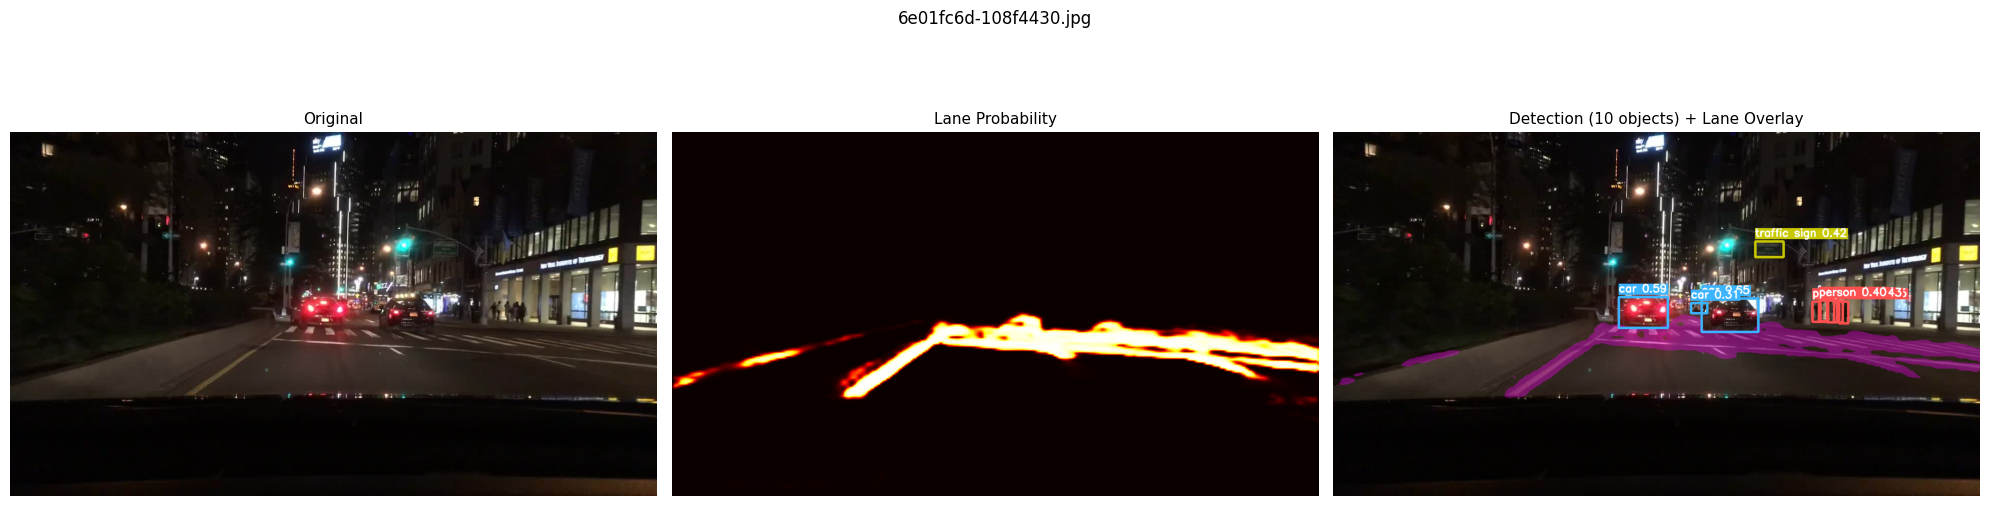

  Objects Detected: 10
  Lane coverage: 4.8% of image



In [6]:
# BDD100K class names
BDD_CLASSES = [
    'person', 'rider', 'car', 'truck', 'bus',
    'train', 'motorcycle', 'bicycle', 'traffic light', 'traffic sign',
]

# Colours for detection boxes
BOX_COLORS = [
    (255,80,80), (255,160,60), (60,180,255), (100,100,255), (255,220,60),
    (180,100,255), (100,255,100), (255,100,200), (0,255,200), (200,200,0),
]

IMG_SIZE = 640

try:
    # Ultralytics (< 8.3.0)
    from ultralytics.utils.ops import non_max_suppression
except ImportError:
    # Ultralytics (>= 8.3.0)
    from ultralytics.utils.nms import non_max_suppression


def run_joint_inference(model, image_path, device, img_size=640, conf_thresh=0.3):
    """
    Run the multi-task model on a single image to extract both Detection Boxes and Lane Masks.
    """
    import cv2
    import numpy as np
    import torch

    img = cv2.imread(image_path)
    orig_h, orig_w = img.shape[:2]

    # Model input logic (simulated ratio squash)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    tensor = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)
    tensor = tensor.permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)

    # 1. Extract Detection Boxes using Ultralytics native NMS decoding
    det_out = outputs['det_output']
    # Ensure inference output format
    if isinstance(det_out, (tuple, list)):
        det_out = det_out[0]

    # Apply standard YOLO Non-Maximum Suppression
    preds = non_max_suppression(det_out, conf_thres=conf_thresh, iou_thres=0.45, max_det=300)
    bboxes = preds[0].cpu().numpy()  # Extract box coordinates

    # Manually rescale bounding boxes back to original shape since we performed unproportional squash in cv2.resize
    # Do not use scale_boxes() as it assumes LetterBox transform padding.
    if len(bboxes):
        bboxes[:, [0, 2]] *= (orig_w / img_size)
        bboxes[:, [1, 3]] *= (orig_h / img_size)
        bboxes[:, :4] = bboxes[:, :4].round()

    # 2. Extract Lane Mask Probabilities
    lane_logits = outputs['lane_logits']
    lane_prob = torch.sigmoid(lane_logits)[0, 0].cpu().numpy()

    return img, bboxes, lane_prob

def visualize_joint_result(img, bboxes, lane_prob, image_path, save_path=None,
                           lane_thresh=0.5, lane_color=(255, 0, 255)):
    """
    Visualize detection bounding boxes + lane mask overlay on the original image.
    """
    import cv2
    import numpy as np
    import os
    import matplotlib.pyplot as plt

    h, w = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. Overlay Lane Mask
    lane_mask = cv2.resize(lane_prob, (w, h), interpolation=cv2.INTER_LINEAR)
    lane_binary = (lane_mask > lane_thresh).astype(np.uint8)

    overlay = img_rgb.copy()
    overlay[lane_binary == 1] = lane_color
    blended = cv2.addWeighted(img_rgb, 0.65, overlay, 0.35, 0)

    # 2. Draw YOLO Bounding Boxes
    for box in bboxes:
        x1, y1, x2, y2, conf, cls = box
        color = BOX_COLORS[int(cls) % len(BOX_COLORS)]
        label = f"{BDD_CLASSES[int(cls)]} {conf:.2f}"

        cv2.rectangle(blended, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)

        # Custom background label style for better readability, robust against out-of-bounds mapping
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        y_text = int(y1) - 5 if int(y1) - 5 > th else int(y1) + th + 5
        cv2.rectangle(blended, (int(x1), y_text - th - 5), (int(x1) + tw, y_text), color, -1)
        cv2.putText(blended, label, (int(x1), y_text - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Render Plt
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(lane_mask, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('Lane Probability', fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(blended)
    axes[2].set_title(f'Detection ({len(bboxes)} objects) + Lane Overlay', fontsize=11)
    axes[2].axis('off')

    plt.suptitle(os.path.basename(image_path), fontsize=12)
    plt.tight_layout()

    if save_path:
        # Create dir if not exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"💾 Saved to {save_path}")

    plt.show()
    return blended

# Re-run inference across all validation samples
if 'test_images' in locals() and len(test_images) > 0:
    for img_path in test_images:
        img, bboxes, lane_prob = run_joint_inference(model, img_path, device, IMG_SIZE)

        save_path = os.path.join(OUTPUT_DIR, f"joint_{os.path.basename(img_path).replace('.jpg', '.png')}")
        visualize_joint_result(img, bboxes, lane_prob, img_path, save_path=save_path)

        # Fix shape calculations just in case
        lane_pct = (lane_prob > 0.5).mean() * 100
        print(f"  Objects Detected: {len(bboxes)}")
        print(f"  Lane coverage: {lane_pct:.1f}% of image\n")
else:
    print("❌ No test images found. Please run cell 3 to select images.")


## 5 — Compare: Detection-Only vs Joint Model

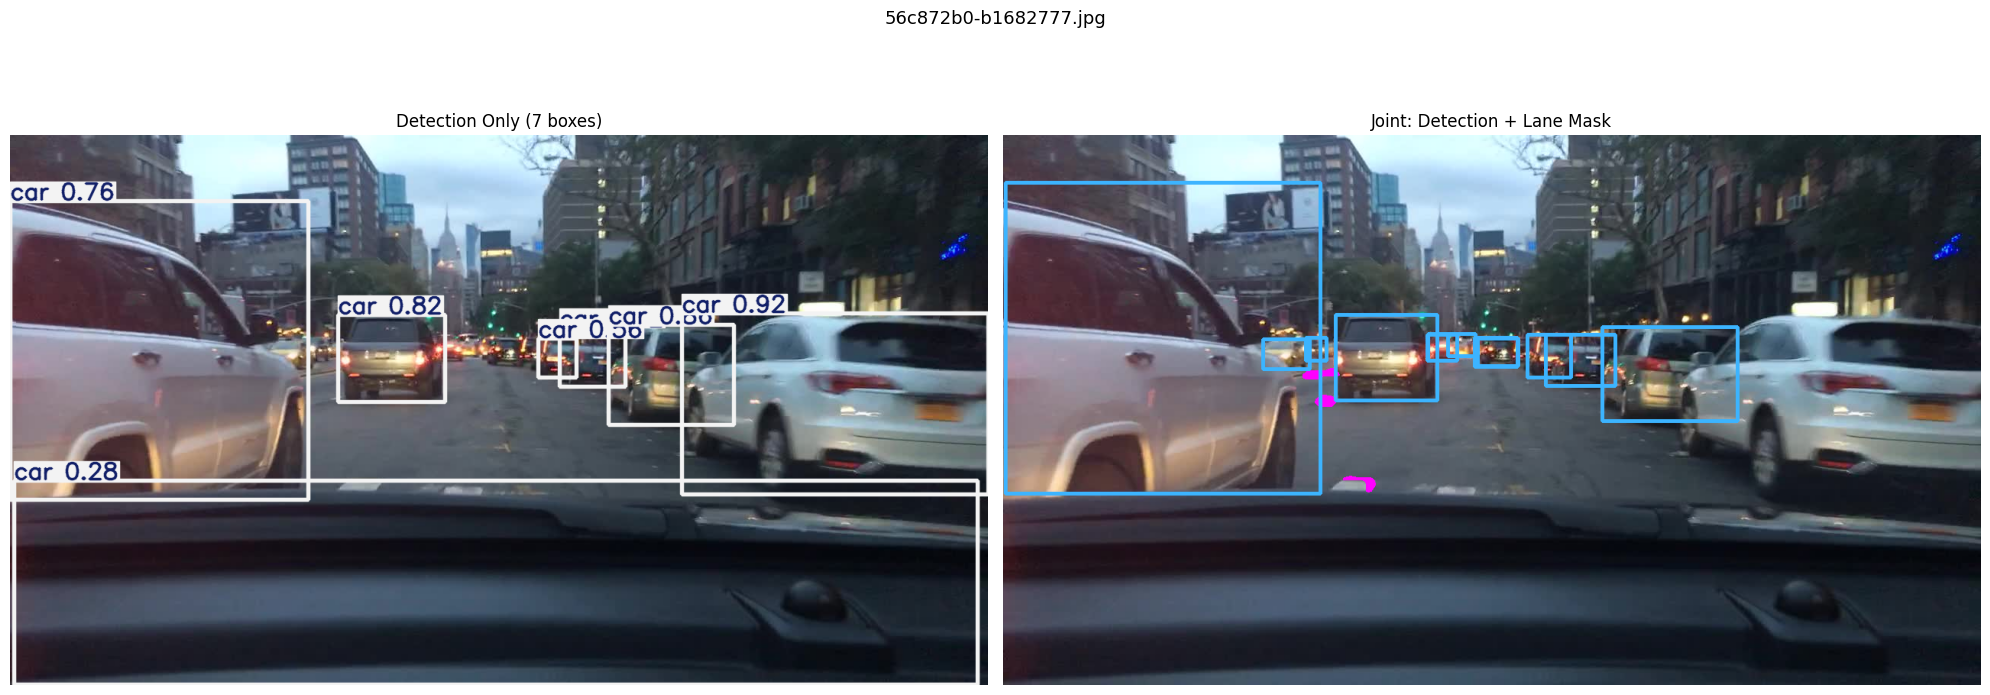

💾 /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/compare_56c872b0-b1682777.png


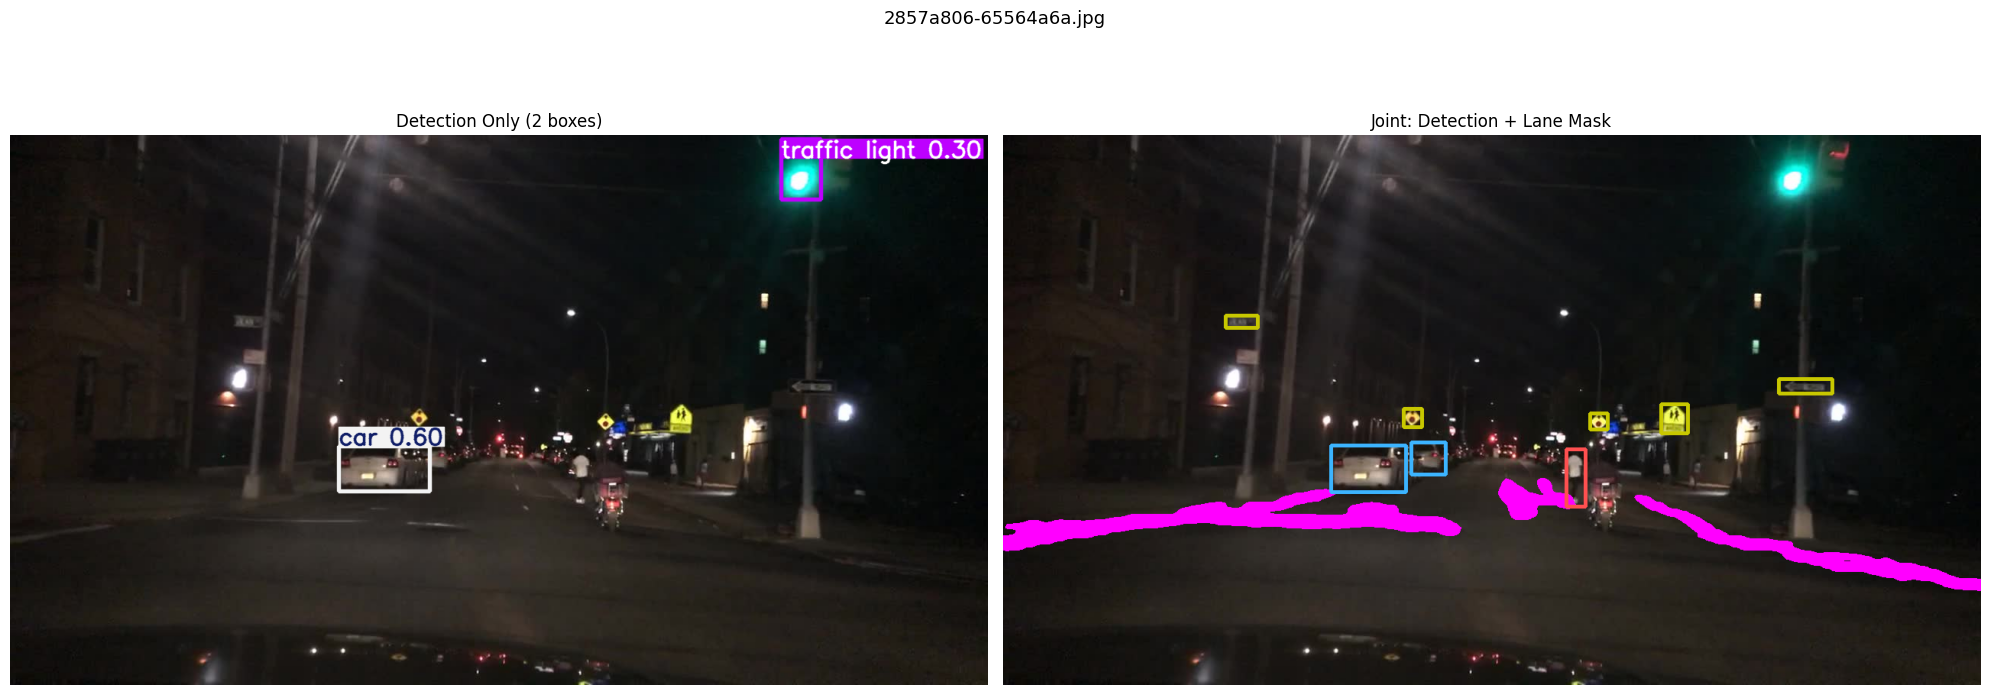

💾 /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference/compare_2857a806-65564a6a.png


In [7]:
from ultralytics import YOLO

# Load detection-only model for comparison
det_only_weights = os.path.join(ECOCAR_ROOT, 'weights', 'bdd100k_yolo26s_best.pt')
if os.path.isfile(det_only_weights):
    det_model = YOLO(det_only_weights)
else:
    det_model = YOLO('yolo26n.pt')  # Fallback to pretrained

# Compare on first 2 images
for img_path in test_images[:2]:
    # Detection-only
    det_result = det_model(img_path, verbose=False)[0]
    det_annotated = det_result.plot()

    # Joint model
    img, bboxes, lane_prob = run_joint_inference(model, img_path, device, IMG_SIZE)
    h, w = img.shape[:2]
    lane_mask = cv2.resize(lane_prob, (w, h)) > 0.5

    joint_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    joint_vis[lane_mask] = [255, 0, 255]  # Magenta lanes

    # Draw Joint YOLO Bounding Boxes
    for box in bboxes:
        x1, y1, x2, y2, conf, cls = box
        color = BOX_COLORS[int(cls) % len(BOX_COLORS)]
        cv2.rectangle(joint_vis, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    ax1.imshow(cv2.cvtColor(det_annotated, cv2.COLOR_BGR2RGB))
    ax1.set_title(f'Detection Only ({len(det_result.boxes)} boxes)', fontsize=12)
    ax1.axis('off')
    ax2.imshow(joint_vis)
    ax2.set_title('Joint: Detection + Lane Mask', fontsize=12)
    ax2.axis('off')
    plt.suptitle(os.path.basename(img_path), fontsize=13)
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"compare_{os.path.basename(img_path).replace('.jpg', '.png')}")
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"💾 {save_path}")

## 6 — How to Reuse Joint Model

```python
import torch
from src.multitask_model import build_multitask_model

# Build model (same architecture as training)
model = build_multitask_model('yolo26s.pt', mask_height=180, mask_width=320)

# Load joint weights
ckpt = torch.load('joint_det_lane_best.pt', map_location='cuda')
model.load_state_dict(ckpt['model_state_dict'])
model.eval().cuda()

# Inference
img_tensor = preprocess(image)  # (1, 3, 640, 640)
outputs = model(img_tensor)

det_output = outputs['det_output']      # Detection predictions
lane_logits = outputs['lane_logits']    # Lane segmentation logits
lane_prob = torch.sigmoid(lane_logits)  # Lane probabilities
neck_features = outputs['neck_features'] # Reusable features
```

In [8]:
print("\n" + "="*60)
print(" JOINT INFERENCE — COMPLETE")
print("="*60)
print(f" Weights:   {JOINT_WEIGHTS}")
print(f" Images:    {len(test_images)}")
print(f" Saved to:  {OUTPUT_DIR}")
print("="*60)
print("\n🎯 The joint model produces both detection boxes and lane segmentation!")
print("   Use the shared backbone features for further downstream tasks.")


 JOINT INFERENCE — COMPLETE
 Weights:   /content/drive/MyDrive/EcoCAR/weights/joint_det_lane_best.pt
 Images:    6
 Saved to:  /content/drive/MyDrive/EcoCAR/outputs/09_joint_inference

🎯 The joint model produces both detection boxes and lane segmentation!
   Use the shared backbone features for further downstream tasks.


### 📊 Joint Evaluation Metrics

To comprehensively evaluate the multi-task model, we calculate two parallel metrics:
1. **Bounding Box Detection**: **mAP (Mean Average Precision)**. Measures how accurately the predicted boxes align with ground-truth objects across various confidence thresholds (mAP@50 and mAP@50-95).
2. **Lane Segmentation**: **mIoU (Mean Intersection over Union)**. Measures the pixel-perfect overlap between the predicted lane mask and the true lane mask.

We use `torchmetrics` to evaluate the YOLO bounding boxes natively alongside segmentation.

In [9]:
!pip install -q "torchmetrics[detection]"
from src.visualization_utils import evaluate_joint_metrics

val_labels_dir = os.path.join(DATASET_DIR, 'labels', 'val')
val_masks_dir = os.path.join(DATASET_DIR, 'masks', 'val')

# Run unified evaluation!
metrics = evaluate_joint_metrics(
    model=model,
    device=device,
    val_images_dir=val_images_dir,
    val_labels_dir=val_labels_dir,
    val_masks_dir=val_masks_dir,
    conf_thresh=0.001,     # Capture deep tail for accurate mAP
    nms_iou_thresh=0.6,     # Standard YOLO NMS threshold
    max_det=300          # Standard YOLO max detections
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.9 MB/s eta 0:00:00
⏳ Evaluating Joint Metrics on 2990 images...
   ↳ mAP config: conf_thresh=0.001, nms_iou_thresh=0.6, max_det=300


Eval:   0%|          | 0/2990 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


\n✅ Validated on 2990 images:
   - Box Diagnostics: 219.5 avg preds/img (Max: 300)
   - Valid mask samples: 2990
\n📈 Calculating final COCO mAP integral (this may take a moment)...
 JOINT EVALUATION RESULTS
 🎯 Bounding Box mAP@50-95:  18.19%
 🎯 Bounding Box mAP@50:     36.72%
 🛣️  Lane Segmentation mIoU:  41.53%
